# Recommendation systems EDA

## Importación de librerías y paquetes y definición de constantes

In [111]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
# split para modelado
from sklearn.model_selection import train_test_split
# Scaled | Escalado
from sklearn.preprocessing import StandardScaler, MinMaxScaler, RobustScaler
# Encoding | Codificación
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, OrdinalEncoder
# To save models
import json
import pickle
# from tqdm import tqdm
import warnings

In [112]:
warnings.filterwarnings("ignore")

## Recopilación de datos

In [113]:
df = pd.read_csv("../data/raw/adult-census-income.csv")
df.head()

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K


## Análisis descriptivo 

In [114]:
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K


In [116]:
df.shape

(32561, 15)

In [117]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32561 entries, 0 to 32560
Data columns (total 15 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   age             32561 non-null  int64 
 1   workclass       32561 non-null  object
 2   fnlwgt          32561 non-null  int64 
 3   education       32561 non-null  object
 4   education.num   32561 non-null  int64 
 5   marital.status  32561 non-null  object
 6   occupation      32561 non-null  object
 7   relationship    32561 non-null  object
 8   race            32561 non-null  object
 9   sex             32561 non-null  object
 10  capital.gain    32561 non-null  int64 
 11  capital.loss    32561 non-null  int64 
 12  hours.per.week  32561 non-null  int64 
 13  native.country  32561 non-null  object
 14  income          32561 non-null  object
dtypes: int64(6), object(9)
memory usage: 3.7+ MB


In [118]:
df.nunique()

age                  73
workclass             9
fnlwgt            21648
education            16
education.num        16
marital.status        7
occupation           15
relationship          6
race                  5
sex                   2
capital.gain        119
capital.loss         92
hours.per.week       94
native.country       42
income                2
dtype: int64

In [119]:
df.groupby('occupation')['capital.gain'].mean().sort_values(ascending=False)

occupation
Prof-specialty       2726.699517
Exec-managerial      2262.772996
Sales                1319.829315
Protective-serv       708.098613
Tech-support          673.552802
Craft-repair          649.512808
?                     604.491047
Farming-fishing       589.726358
Adm-clerical          495.954907
Transport-moving      490.323732
Machine-op-inspct     328.689311
Priv-house-serv       279.852349
Handlers-cleaners     257.572993
Other-service         191.301669
Armed-Forces            0.000000
Name: capital.gain, dtype: float64

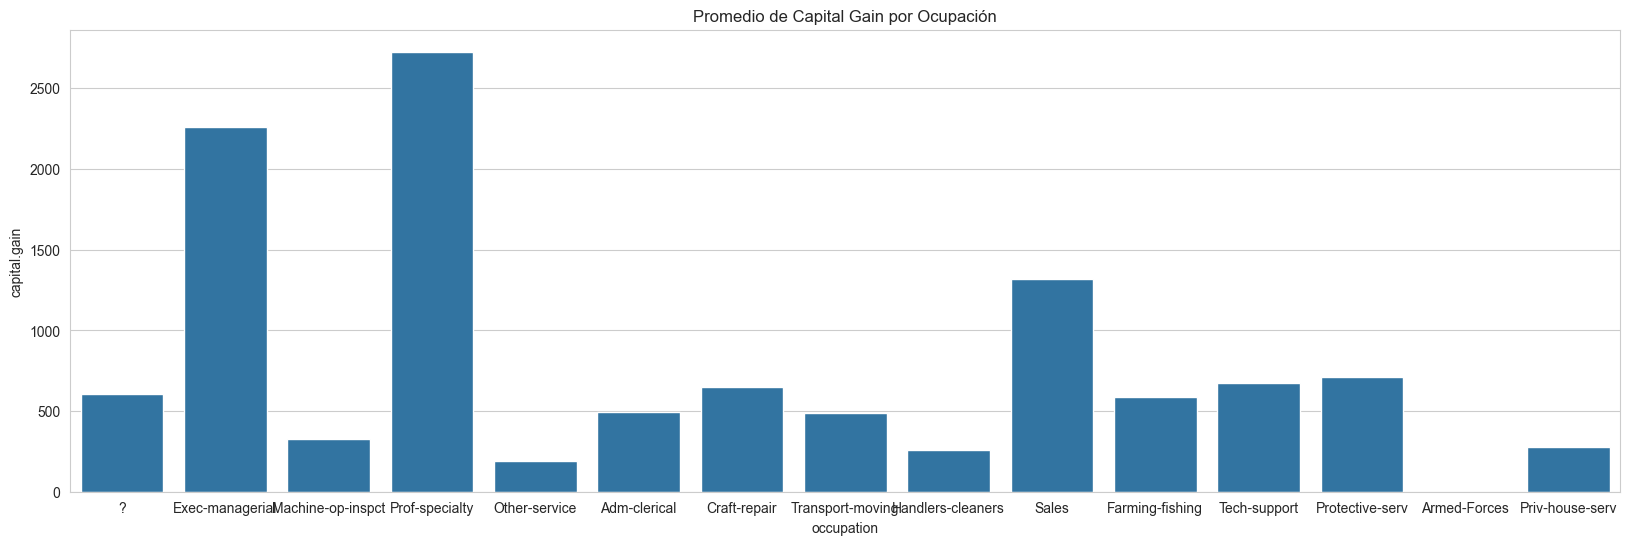

In [ ]:
plt.figure(figsize=(20,6))
sns.barplot(data=df, x='occupation', y='capital.gain', estimator='mean', ci=None)
plt.title("Promedio de capital gain por ocupación")
plt.show()

In [121]:
df.groupby('occupation')['capital.loss'].mean().sort_values(ascending=False)

occupation
Armed-Forces         209.666667
Exec-managerial      138.838416
Prof-specialty       136.139372
Tech-support          98.665948
Sales                 98.300548
Craft-repair          88.465235
Transport-moving      81.480902
Protective-serv       78.334361
Farming-fishing       63.075453
Machine-op-inspct     61.706294
Adm-clerical          60.794430
?                     60.529571
Handlers-cleaners     45.635766
Other-service         38.250683
Priv-house-serv       21.449664
Name: capital.loss, dtype: float64

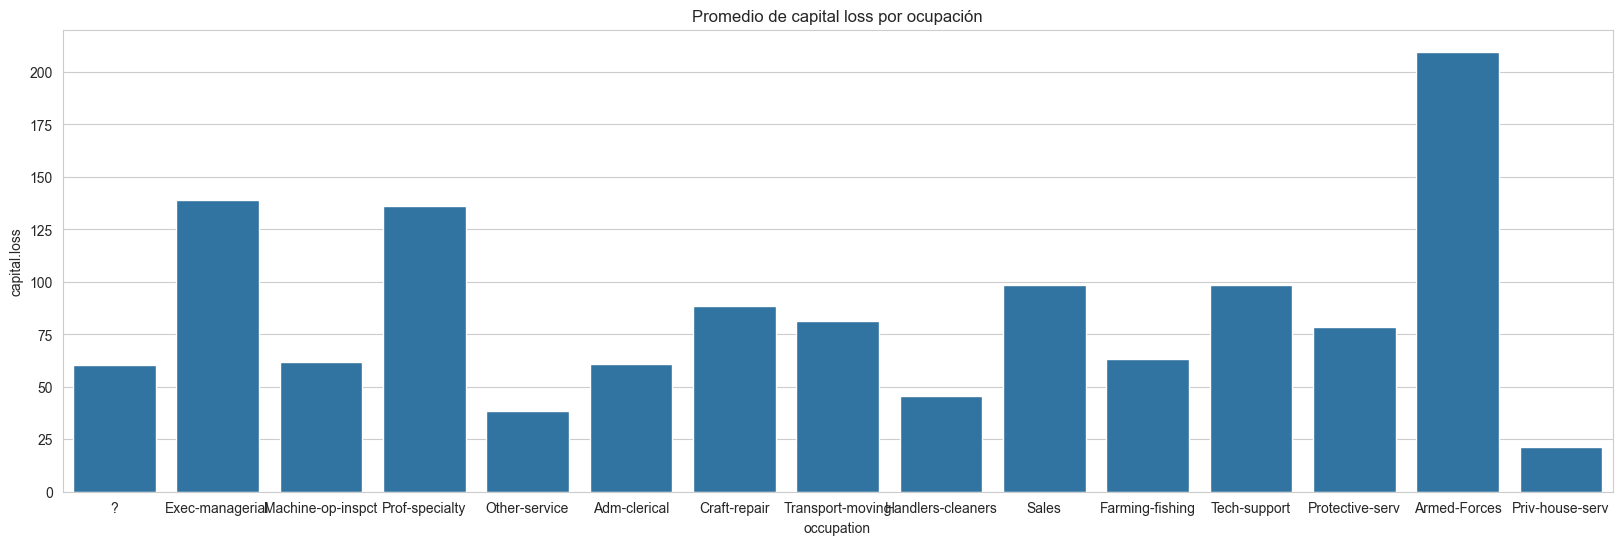

In [122]:
plt.figure(figsize=(20,6))
sns.barplot(data=df, x='occupation', y='capital.loss', estimator='mean', ci=None)
plt.title("Promedio de capital loss por ocupación")
plt.show()

In [123]:
df['capital.net'] = df['capital.gain'] - df['capital.loss']

In [125]:
df.groupby('occupation')['capital.net'].mean().sort_values(ascending=False)

occupation
Prof-specialty       2590.560145
Exec-managerial      2123.934579
Sales                1221.528767
Protective-serv       629.764253
Tech-support          574.886853
Craft-repair          561.047573
?                     543.961476
Farming-fishing       526.650905
Adm-clerical          435.160477
Transport-moving      408.842830
Machine-op-inspct     266.983017
Priv-house-serv       258.402685
Handlers-cleaners     211.937226
Other-service         153.050986
Armed-Forces         -209.666667
Name: capital.net, dtype: float64

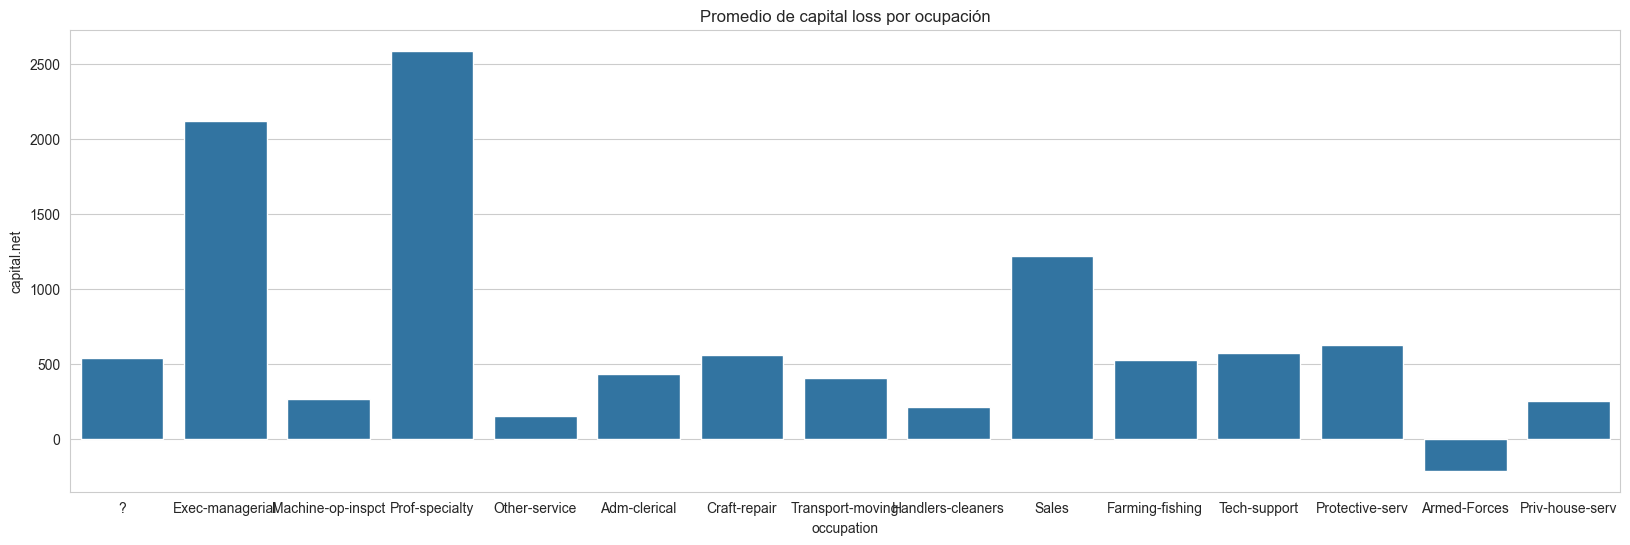

In [124]:
plt.figure(figsize=(20,6))
sns.barplot(data=df, x='occupation', y='capital.net', estimator='mean', ci=None)
plt.title("Promedio de capital loss por ocupación")
plt.show()

### Observamos una relación clara entre la ocupación y la pérdida o ganancia de capital

## Limpieza de datos

### Eliminar duplicados:

In [126]:
df.duplicated().sum()

24

### Hay datos duplicados, así que nos aseguramos de borrarlos

In [127]:
if df.duplicated().sum():
    df = df.drop_duplicates(keep='first')
print(df.shape)
df.head()

(32537, 16)


,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital.net
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K,-4356
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,-4356
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,-4356
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,-3900
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,-3900


In [128]:
df.duplicated().sum()

0

### Valores nulos o faltantes:

In [132]:
df.isnull().sum().sort_values(ascending=False) / len(df)

age               0.0
workclass         0.0
fnlwgt            0.0
education         0.0
education.num     0.0
marital.status    0.0
occupation        0.0
relationship      0.0
race              0.0
sex               0.0
capital.gain      0.0
capital.loss      0.0
hours.per.week    0.0
native.country    0.0
income            0.0
capital.net       0.0
dtype: float64

#### No hay valores nulos a primera vista, aunque observamos que existe falta de datos

In [133]:
df[df['workclass']== '?']

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital.net
0,90,?,77053,HS-grad,9,Widowed,?,Not-in-family,White,Female,0,4356,40,United-States,<=50K,-4356
2,66,?,186061,Some-college,10,Widowed,?,Unmarried,Black,Female,0,4356,40,United-States,<=50K,-4356
14,51,?,172175,Doctorate,16,Never-married,?,Not-in-family,White,Male,0,2824,40,United-States,>50K,-2824
24,61,?,135285,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2603,32,United-States,<=50K,-2603
44,71,?,100820,HS-grad,9,Married-civ-spouse,?,Husband,White,Male,0,2489,15,United-States,<=50K,-2489
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32533,35,?,320084,Bachelors,13,Married-civ-spouse,?,Wife,White,Female,0,0,55,United-States,>50K,0
32534,30,?,33811,Bachelors,13,Never-married,?,Not-in-family,Asian-Pac-Islander,Female,0,0,99,United-States,<=50K,0
32541,71,?,287372,Doctorate,16,Married-civ-spouse,?,Husband,White,Male,0,0,10,United-States,>50K,0
32543,41,?,202822,HS-grad,9,Separated,?,Not-in-family,Black,Female,0,0,32,United-States,<=50K,0


In [141]:
df[df['occupation']== '?']

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital.net


In [140]:
df[(df['occupation']== '?')|(df['workclass']== '?')]

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital.net


In [139]:
df.replace('?', np.nan, inplace=True)
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital.net
0,90,NaN,77053,HS-grad,9,Widowed,NaN,Not-in-family,White,Female,0,4356,40,United-States,<=50K,-4356
1,82,Private,132870,HS-grad,9,Widowed,Exec-managerial,Not-in-family,White,Female,0,4356,18,United-States,<=50K,-4356
2,66,NaN,186061,Some-college,10,Widowed,NaN,Unmarried,Black,Female,0,4356,40,United-States,<=50K,-4356
3,54,Private,140359,7th-8th,4,Divorced,Machine-op-inspct,Unmarried,White,Female,0,3900,40,United-States,<=50K,-3900
4,41,Private,264663,Some-college,10,Separated,Prof-specialty,Own-child,White,Female,0,3900,40,United-States,<=50K,-3900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,Private,310152,Some-college,10,Never-married,Protective-serv,Not-in-family,White,Male,0,0,40,United-States,<=50K,0
32557,27,Private,257302,Assoc-acdm,12,Married-civ-spouse,Tech-support,Wife,White,Female,0,0,38,United-States,<=50K,0
32558,40,Private,154374,HS-grad,9,Married-civ-spouse,Machine-op-inspct,Husband,White,Male,0,0,40,United-States,>50K,0
32559,58,Private,151910,HS-grad,9,Widowed,Adm-clerical,Unmarried,White,Female,0,0,40,United-States,<=50K,0


In [142]:
df.isnull().sum().sort_values(ascending=False) / len(df)

occupation        0.056643
workclass         0.056428
native.country    0.017887
age               0.000000
fnlwgt            0.000000
education         0.000000
education.num     0.000000
marital.status    0.000000
relationship      0.000000
race              0.000000
sex               0.000000
capital.gain      0.000000
capital.loss      0.000000
hours.per.week    0.000000
income            0.000000
capital.net       0.000000
dtype: float64

### Convertimos los valores raros en nulos para poder contabilizarlos y eliminarlos

In [145]:
df.dropna(inplace=True)

### Limpieza de datos: Eliminar información irrelevante, para ello transformamos las variables categóricas en númericas

In [143]:
columnas_categoricas = df.select_dtypes(include=['object', 'category']).columns.tolist()
#columnas_categoricas = [col for col in columnas_categoricas if col != df.select_dtypes(include=['int64', 'float64']).columns.tolist()]
encoders = {} 
for columna in columnas_categoricas:
    le = LabelEncoder()
    df[columna] = le.fit_transform(df[columna])
    encoders[columna] = le
df

,age,workclass,fnlwgt,education,education.num,marital.status,occupation,relationship,race,sex,capital.gain,capital.loss,hours.per.week,native.country,income,capital.net
0,90,8,77053,11,9,6,14,1,4,0,0,4356,40,38,0,-4356
1,82,3,132870,11,9,6,3,1,4,0,0,4356,18,38,0,-4356
2,66,8,186061,15,10,6,14,4,2,0,0,4356,40,38,0,-4356
3,54,3,140359,5,4,0,6,4,4,0,0,3900,40,38,0,-3900
4,41,3,264663,15,10,5,9,3,4,0,0,3900,40,38,0,-3900
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,22,3,310152,15,10,4,10,1,4,1,0,0,40,38,0,0
32557,27,3,257302,7,12,2,12,5,4,0,0,0,38,38,0,0
32558,40,3,154374,11,9,2,6,0,4,1,0,0,40,38,1,0
32559,58,3,151910,11,9,6,0,4,4,0,0,0,40,38,0,0


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32537 entries, 0 to 32560
Data columns (total 16 columns):
 #   Column          Non-Null Count  Dtype
---  ------          --------------  -----
 0   age             32537 non-null  int64
 1   workclass       32537 non-null  int32
 2   fnlwgt          32537 non-null  int64
 3   education       32537 non-null  int32
 4   education.num   32537 non-null  int64
 5   marital.status  32537 non-null  int32
 6   occupation      32537 non-null  int32
 7   relationship    32537 non-null  int32
 8   race            32537 non-null  int32
 9   sex             32537 non-null  int32
 10  capital.gain    32537 non-null  int64
 11  capital.loss    32537 non-null  int64
 12  hours.per.week  32537 non-null  int64
 13  native.country  32537 non-null  int32
 14  income          32537 non-null  int32
 15  capital.net     32537 non-null  int64
dtypes: int32(9), int64(7)
memory usage: 3.1 MB


In [148]:
corr_income = df.corr()['income'].drop('income').abs().sort_values(ascending=False)
corr_income

education.num     0.335272
relationship      0.250948
age               0.234037
hours.per.week    0.229658
capital.gain      0.223336
sex               0.215969
capital.net       0.214437
marital.status    0.199199
capital.loss      0.150501
education         0.079366
race              0.071847
workclass         0.055180
native.country    0.022957
occupation        0.010674
fnlwgt            0.009502
Name: income, dtype: float64

In [94]:
df['capital.gain'].value_counts()

capital.gain
0        29825
15024      347
7688       284
7298       246
99999      159
         ...  
1111         1
4931         1
7978         1
5060         1
2538         1
Name: count, Length: 119, dtype: int64

In [95]:
df['capital.loss'].value_counts()

capital.loss
0       31018
1902      202
1977      168
1887      159
1485       51
        ...  
2201        1
2163        1
1944        1
1539        1
2472        1
Name: count, Length: 92, dtype: int64

#### Existen algunas variables redundantes que quizás podamos eliminar o combinar

In [96]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.585549,13.637984,17.0,28.0,37.0,48.0,90.0
workclass,32537.0,3.376587,1.582564,0.0,3.0,3.0,3.0,8.0
fnlwgt,32537.0,189780.848511,105556.471009,12285.0,117827.0,178356.0,236993.0,1484705.0
education,32537.0,10.297507,3.870142,0.0,9.0,11.0,12.0,15.0
education.num,32537.0,10.081815,2.571633,1.0,9.0,10.0,12.0,16.0
marital.status,32537.0,2.611427,1.506301,0.0,2.0,2.0,4.0,6.0
occupation,32537.0,6.422504,4.329257,0.0,3.0,6.0,10.0,14.0
relationship,32537.0,1.446538,1.607064,0.0,0.0,1.0,3.0,5.0
race,32537.0,3.665827,0.848847,0.0,4.0,4.0,4.0,4.0
sex,32537.0,0.669238,0.470495,0.0,0.0,1.0,1.0,1.0


## Análisis de variables:

### Variables univariante: variables númericas

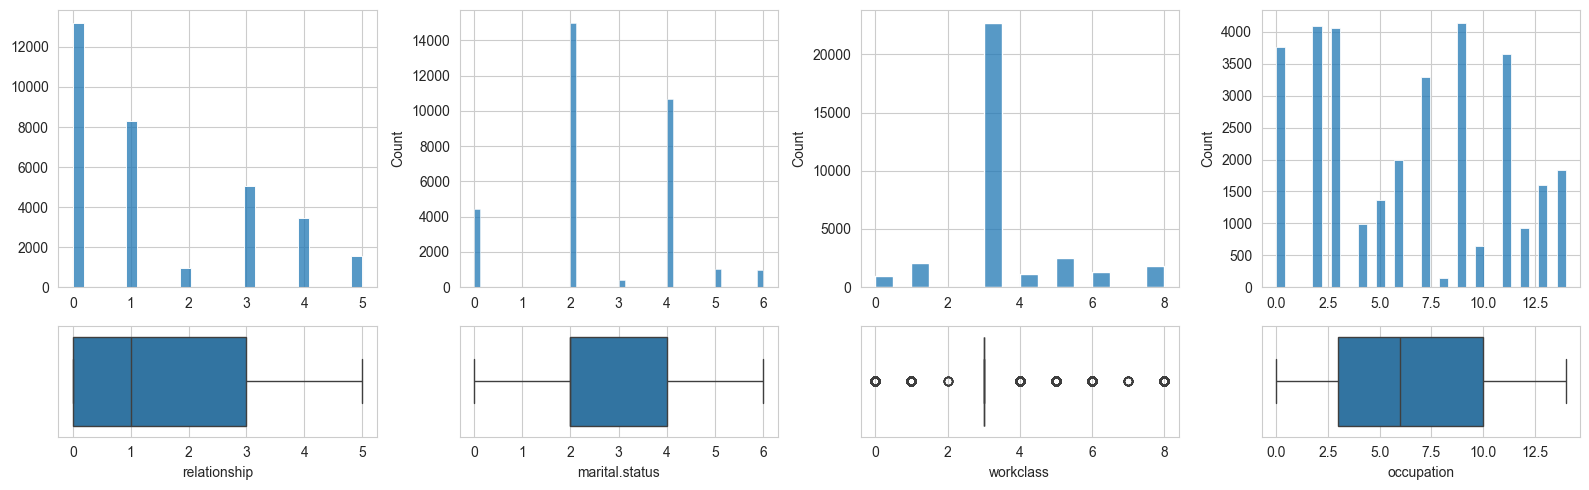

In [97]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="relationship").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="relationship")
sns.histplot(ax=axis[0, 1], data=df, x="marital.status").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="marital.status")
sns.histplot(ax=axis[0, 2], data=df, x="workclass").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="workclass")
sns.histplot(ax=axis[0, 3], data=df, x="occupation").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="occupation")
plt.tight_layout()
plt.show()

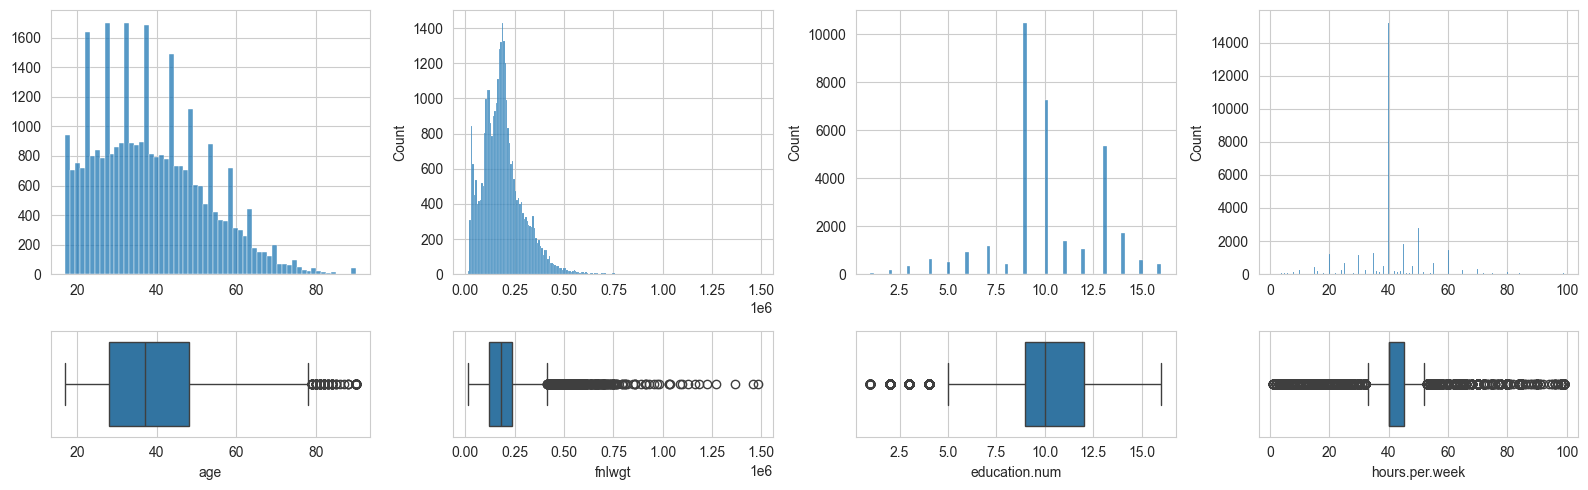

In [98]:
fig, axis = plt.subplots(2, 4, figsize=(16, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="age").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="age")
sns.histplot(ax=axis[0, 1], data=df, x="fnlwgt").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="fnlwgt")
sns.histplot(ax=axis[0, 2], data=df, x="education.num").set(xlabel=None)
sns.boxplot(ax=axis[1, 2], data=df, x="education.num")
sns.histplot(ax=axis[0, 3], data=df, x="hours.per.week").set(xlabel=None)
sns.boxplot(ax=axis[1, 3], data=df, x="hours.per.week")
plt.tight_layout()
plt.show()

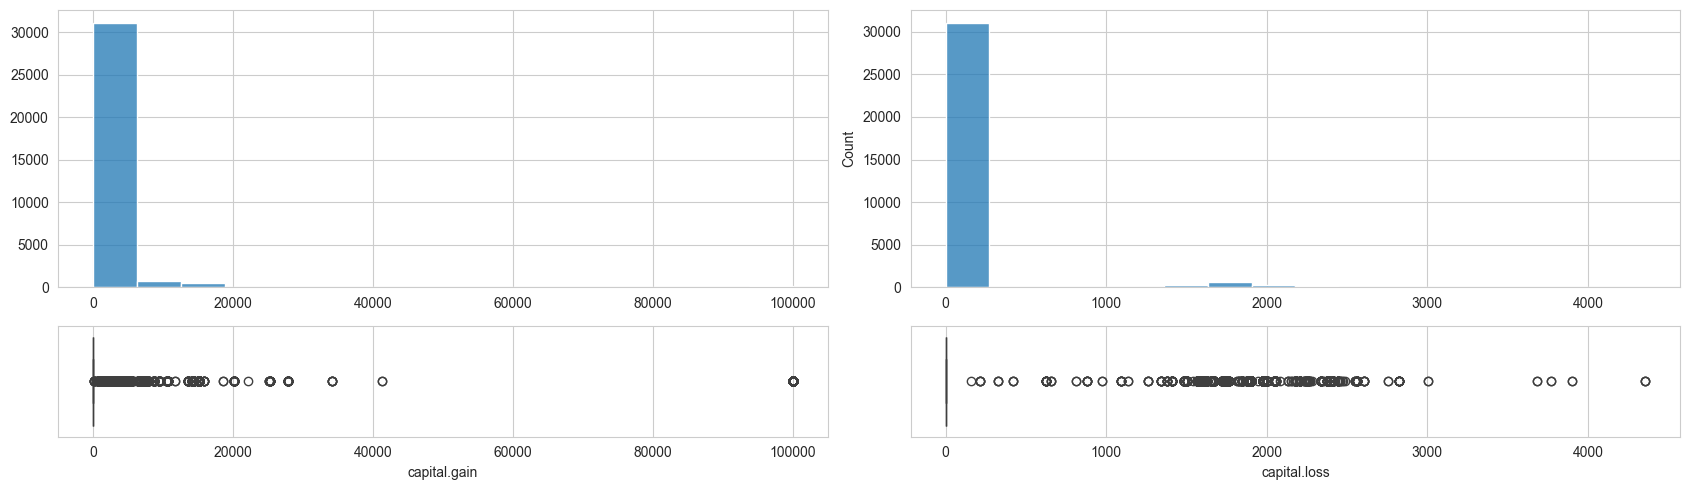

In [99]:
fig, axis = plt.subplots(2, 2, figsize=(17, 5), gridspec_kw={'height_ratios': [5, 2]})
sns.set_style("whitegrid")
sns.histplot(ax=axis[0, 0], data=df, x="capital.gain").set(xlabel=None, ylabel=None)
sns.boxplot(ax=axis[1, 0], data=df, x="capital.gain")
sns.histplot(ax=axis[0, 1], data=df, x="capital.loss").set(xlabel=None)
sns.boxplot(ax=axis[1, 1], data=df, x="capital.loss")


plt.tight_layout()
plt.show()

### Análisis de Variables Multivariante: procedemos a buscar todas las posibles relaciones que existen entre las variables

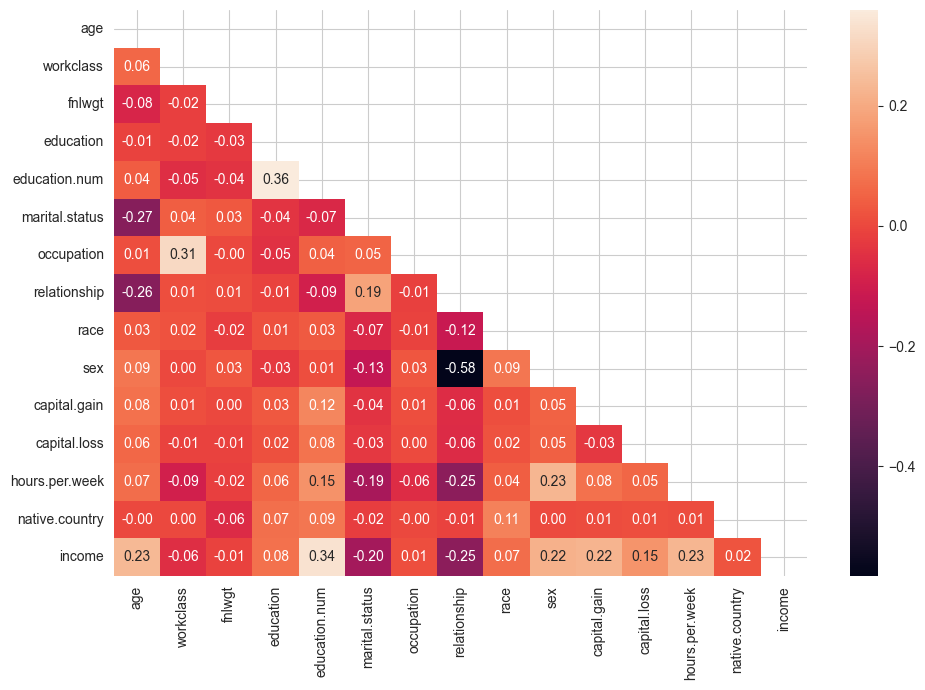

In [100]:
corr = df.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")
plt.tight_layout()
plt.show()

### Observaciones:

#### Nos quedaremos con las variables más relacionadas con la variable income que utilizaremos como variable objetivo

## Ingeniería de características

### Análisis de outliers

#### Análisis descriptivo

In [101]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
age,32537.0,38.585549,13.637984,17.0,28.0,37.0,48.0,90.0
workclass,32537.0,3.376587,1.582564,0.0,3.0,3.0,3.0,8.0
fnlwgt,32537.0,189780.848511,105556.471009,12285.0,117827.0,178356.0,236993.0,1484705.0
education,32537.0,10.297507,3.870142,0.0,9.0,11.0,12.0,15.0
education.num,32537.0,10.081815,2.571633,1.0,9.0,10.0,12.0,16.0
marital.status,32537.0,2.611427,1.506301,0.0,2.0,2.0,4.0,6.0
occupation,32537.0,6.422504,4.329257,0.0,3.0,6.0,10.0,14.0
relationship,32537.0,1.446538,1.607064,0.0,0.0,1.0,3.0,5.0
race,32537.0,3.665827,0.848847,0.0,4.0,4.0,4.0,4.0
sex,32537.0,0.669238,0.470495,0.0,0.0,1.0,1.0,1.0


#### Visualización

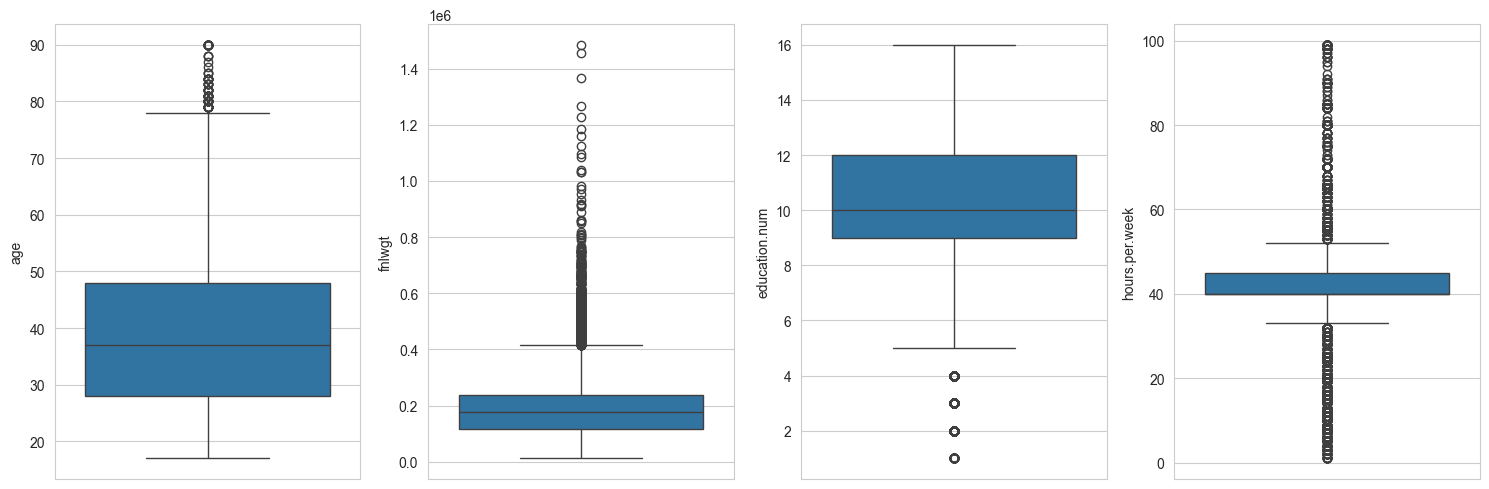

In [102]:
fig, axis = plt.subplots(1, 4, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="age")
sns.boxplot(ax=axis[1], data=df, y="fnlwgt")
sns.boxplot(ax=axis[2], data=df, y="education.num")
sns.boxplot(ax=axis[3], data=df, y="hours.per.week")
plt.tight_layout()
plt.show()

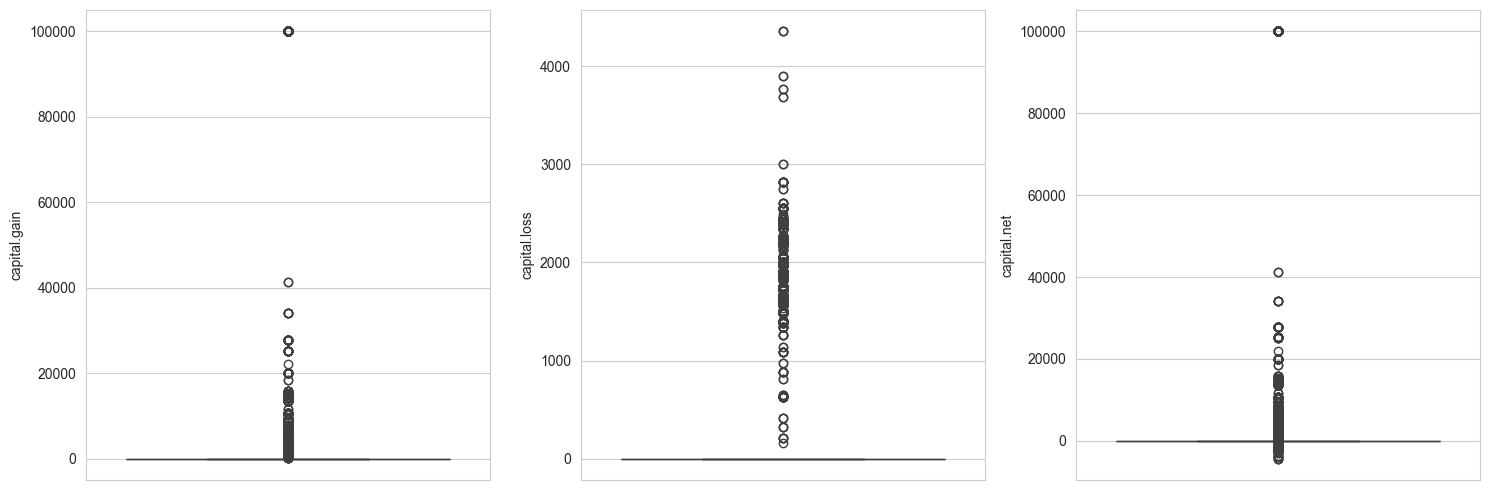

In [149]:
fig, axis = plt.subplots(1, 3, figsize=(15, 5))
sns.set_style("whitegrid")
sns.boxplot(ax=axis[0], data=df, y="capital.gain")
sns.boxplot(ax=axis[1], data=df, y="capital.loss")
sns.boxplot(ax=axis[2], data=df, y="capital.net")
plt.tight_layout()
plt.show()

### Existen valores atípicos para algunas variables, la mayoría representa valores lógicos excepto quizás la variable hours.per.week que tiene picos muy altos por encima del doble de una jornada laboral normal. Por ahora no voy a tratarlos, para ver como se comporta el modelo así

In [105]:
corr_income

education.num     0.335272
relationship      0.250948
age               0.234037
hours.per.week    0.229658
capital.gain      0.223336
sex               0.215969
marital.status    0.199199
capital.loss      0.150501
education         0.079366
race              0.071847
workclass         0.055180
native.country    0.022957
occupation        0.010674
fnlwgt            0.009502
Name: income, dtype: float64

In [ ]:
df_final = df[['education.num', 'occupation', 'workclass', 'relationship', 'age', 'hours.per.week', 'sex', 'marital.status', 'capital.gain', 'capital.loss', 'income']]
df_final

,education.num,relationship,age,hours.per.week,sex,marital.status,capital.gain,capital.loss,income
0,9,1,90,40,0,6,0,4356,0
1,9,1,82,18,0,6,0,4356,0
2,10,4,66,40,0,6,0,4356,0
3,4,4,54,40,0,0,0,3900,0
4,10,3,41,40,0,5,0,3900,0
...,...,...,...,...,...,...,...,...,...
32556,10,1,22,40,1,4,0,0,0
32557,12,5,27,38,0,2,0,0,0
32558,9,0,40,40,1,2,0,0,1
32559,9,4,58,40,0,6,0,0,0


### Procedemos a trabajar con estas variables para hacer un sistema de recomendación

## Split de datos

In [ ]:
X = df_final.drop(['income'], axis=1)
y = df_final['income']
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=24)
X_train

## Scaling & Encoding

In [ ]:
X_train_num = X_train.select_dtypes(include=['int32', 'int64']).columns.tolist()
X_test_num = X_test.select_dtypes(include=['int32', 'int64']).columns.tolist()

### Encoding con OneHotEncoder

In [ ]:
cat_variables = X_train.select_dtypes(include=['object', 'category']).columns.tolist()
one_hot_encoder = OneHotEncoder(sparse_output=False)
X_train_cat_ohe = one_hot_encoder.fit_transform(X_train[cat_variables])
X_train_cat_ohe = pd.DataFrame(X_train_cat_ohe,
                               index=df_final.index,
                               columns=one_hot_encoder.get_feature_names_out(cat_variables))
X_train_cat_ohe

,occupation_Adm-clerical,occupation_Armed-Forces,occupation_Craft-repair,occupation_Exec-managerial,occupation_Farming-fishing,occupation_Handlers-cleaners,occupation_Machine-op-inspct,occupation_Other-service,occupation_Priv-house-serv,occupation_Prof-specialty,...,sex_Male,marital.status_Divorced,marital.status_Married-AF-spouse,marital.status_Married-civ-spouse,marital.status_Married-spouse-absent,marital.status_Never-married,marital.status_Separated,marital.status_Widowed,income_<=50K,income_>50K
1,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
3,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
4,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,...,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
5,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,...,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0
6,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
32556,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0
32557,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0
32558,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,...,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0
32559,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0
